In [ ]:
!pip install kagglehub xgboost scikit-learn imbalanced-learn matplotlib seaborn --quiet

import kagglehub
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

print("All libraries loaded")

All libraries loaded ✓


In [ ]:
import kagglehub
path = kagglehub.dataset_download("humera11/cicbelldnsexf2021")
print("Path to dataset files:", path)

100%|██████████| 11.6M/11.6M [00:00<00:00, 45.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1


In [ ]:
csv_files = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)
print(f"Found {len(csv_files)} CSV file(s):")
for f in csv_files:
    print("  ", f)

df_list = []
for f in csv_files:
    tmp = pd.read_csv(f, low_memory=False)
    df_list.append(tmp)

df = pd.concat(df_list, ignore_index=True)
print(f"\nMerged shape: {df.shape}")
print(df.head(3))

Found 36 CSV file(s):
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Benign/stateful_features-benign_heavy_3.pcap.csv
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Benign/stateless_features-benign_heavy_1.pcap.csv
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Benign/stateful_features-benign_heavy_1.pcap.csv
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Benign/stateful_features-benign_heavy_2.pcap.csv
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Benign/stateless_features-benign_heavy_3.pcap.csv
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Benign/stateless_features-benign_heavy_2.pcap.csv
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Attacks/stateful_features-heav

In [ ]:
df.head(5)

,rr,A_frequency,NS_frequency,CNAME_frequency,SOA_frequency,NULL_frequency,PTR_frequency,HINFO_frequency,MX_frequency,TXT_frequency,...,numeric,entropy,special,labels,labels_max,labels_average,longest_word,sld,len,subdomain
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Column names")
print(df.columns.tolist())

print("\nData types")
print(df.dtypes)

print("\n Missing values")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nLabel distribution")
label_col = None
for col in df.columns:
    if col.strip().lower() in ['label', 'class', 'target', 'attack_type', 'type']:
        label_col = col
        break

if label_col is None:
    label_col = df.columns[-1]

print(f"Detected label column: '{label_col}'")
print(df[label_col].value_counts())


Column names
['rr', 'A_frequency', 'NS_frequency', 'CNAME_frequency', 'SOA_frequency', 'NULL_frequency', 'PTR_frequency', 'HINFO_frequency', 'MX_frequency', 'TXT_frequency', 'AAAA_frequency', 'SRV_frequency', 'OPT_frequency', 'rr_type', 'rr_count', 'rr_name_entropy', 'rr_name_length', 'distinct_ns', 'distinct_ip', 'unique_country', 'unique_asn', 'distinct_domains', 'reverse_dns', 'a_records', 'unique_ttl', 'ttl_mean', 'ttl_variance', 'timestamp', 'FQDN_count', 'subdomain_length', 'upper', 'lower', 'numeric', 'entropy', 'special', 'labels', 'labels_max', 'labels_average', 'longest_word', 'sld', 'len', 'subdomain']

Data types
rr                  float64
A_frequency         float64
NS_frequency        float64
CNAME_frequency     float64
SOA_frequency       float64
NULL_frequency      float64
PTR_frequency       float64
HINFO_frequency     float64
MX_frequency        float64
TXT_frequency       float64
AAAA_frequency      float64
SRV_frequency       float64
OPT_frequency       float64
rr_

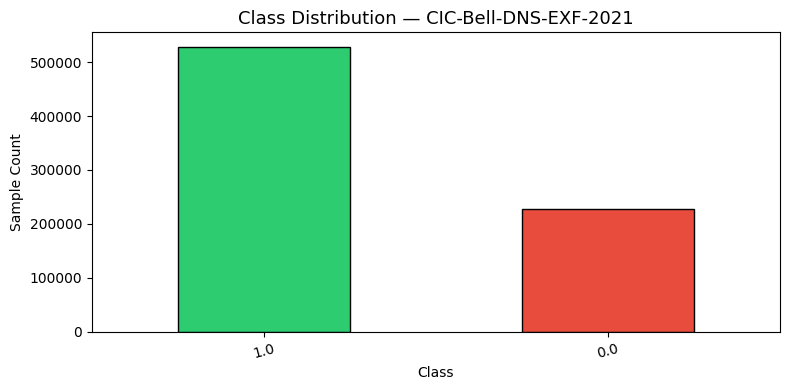

Plot saved


In [ ]:
plt.figure(figsize=(8, 4))
df[label_col].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c','#e67e22'],
                                  edgecolor='black')
plt.title("Class Distribution — CIC-Bell-DNS-EXF-2021", fontsize=13)
plt.xlabel("Class")
plt.ylabel("Sample Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("Plot saved")

In [ ]:
#Separate features and label
X = df.drop(columns=[label_col])
y = df[label_col].copy()

In [ ]:
#Encode any non-numeric feature columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

Categorical columns to encode: ['distinct_ip', 'unique_country', 'unique_asn', 'distinct_domains', 'reverse_dns', 'unique_ttl', 'timestamp', 'longest_word', 'sld']


In [ ]:
#Encode the label
le_label = LabelEncoder()
y_enc = le_label.fit_transform(y.astype(str))
print(f"\nLabel classes: {le_label.classes_}")
num_classes = len(le_label.classes_)


Label classes: ['0.0' '1.0' 'nan']


In [ ]:
# Drop constant or all-NaN columns
X = X.dropna(axis=1, how='all')
X = X.loc[:, X.nunique() > 1]
X = X.fillna(0)

print(f"\nFinal feature matrix: {X.shape}")


Final feature matrix: (1019316, 32)


In [ ]:
df_filtered = df.dropna(subset=[label_col])

X = df_filtered.drop(columns=[label_col])
y = df_filtered[label_col].copy()

print(f"Shape after dropping NaN labels: {df_filtered.shape}")

Shape after dropping NaN labels: (757211, 42)


In [ ]:
# Re-encode any non-numeric feature columns for the filtered data
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

Categorical columns to encode: ['rr_type', 'distinct_ip', 'unique_country', 'unique_asn', 'distinct_domains', 'reverse_dns', 'unique_ttl', 'timestamp', 'longest_word', 'sld']


In [ ]:
# Re-encode the label for the filtered data
le_label = LabelEncoder()
y_enc = le_label.fit_transform(y.astype(str))
print(f"\nLabel classes after filtering: {le_label.classes_}")
num_classes = len(le_label.classes_)
print(f"Number of classes: {num_classes}")


Label classes after filtering: ['0.0' '1.0']
Number of classes: 2


In [ ]:
# Drop constant or all-NaN columns
X = X.dropna(axis=1, how='all')
X = X.loc[:, X.nunique() > 1]
X = X.fillna(0)

print(f"\nFinal feature matrix: {X.shape}")


Final feature matrix: (757211, 14)


In [ ]:
# Split BEFORE any resampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.30, random_state=42, stratify=y_enc
)
print(f"Raw split — Train: {X_train.shape}  |  Test: {X_test.shape}")

Raw split — Train: (530047, 14)  |  Test: (227164, 14)


In [ ]:
# Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42, k_neighbors=3)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE (train only):")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {le_label.classes_[u]}: {c:,}")

print(f"\nTest set is untouched — {X_test.shape[0]:,} real samples")


After SMOTE (train only):
  Class 0.0: 370,363
  Class 1.0: 370,363

Test set is untouched — 227,164 real samples


In [ ]:
# XGBoost with regularization
if num_classes == 2:
    objective = 'binary:logistic'
    eval_metric = 'logloss'
    xgb_num_class = None
else:
    objective = 'multi:softprob'
    eval_metric = 'mlogloss'
    xgb_num_class = num_classes

xgb_model = xgb.XGBClassifier(
    objective         = objective,
    eval_metric       = eval_metric,
    num_class         = xgb_num_class,

    n_estimators      = 500,       # high value — early stopping will cut it short
    max_depth         = 4,         # shallower trees → less overfitting (was 6)
    learning_rate     = 0.05,      # slower learning → better generalisation (was 0.1)
    subsample         = 0.7,       # row sampling per tree (was 0.8)
    colsample_bytree  = 0.7,       # feature sampling per tree (was 0.8)
    min_child_weight  = 10,        # minimum samples in a leaf — key regulariser
    reg_alpha         = 0.1,       # L1 regularisation
    reg_lambda        = 1.5,       # L2 regularisation
    gamma             = 0.1,       # minimum loss reduction to make a split

    use_label_encoder = False,
    tree_method       = "hist",
    random_state      = 42,
    n_jobs            = -1,
    early_stopping_rounds = 20
)

print("Training XGBoost with early stopping…")
xgb_model.fit(
    X_train, y_train,
    eval_set        = [(X_test, y_test)],
    verbose         = 50
)

best = xgb_model.best_iteration
print(f"\nBest iteration: {best} / 500")
print("Training complete ")

Training XGBoost with early stopping…
[0]	validation_0-logloss:0.64440


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [09:50:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[50]	validation_0-logloss:0.04319
[100]	validation_0-logloss:0.00436
[150]	validation_0-logloss:0.00047
[200]	validation_0-logloss:0.00008
[246]	validation_0-logloss:0.00004

Best iteration: 226 / 500
Training complete 


In [ ]:
y_pred      = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)

print("\n" + "="*55)
print("         CLASSIFICATION REPORT")
print("="*55)
print(classification_report(y_test, y_pred,
                             target_names=le_label.classes_))

from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy : {acc*100:.2f}%")

auc = roc_auc_score(y_test, y_pred_prob[:, 1])
print(f"AUC-ROC Score    : {auc:.4f}")


         CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     68437
         1.0       1.00      1.00      1.00    158727

    accuracy                           1.00    227164
   macro avg       1.00      1.00      1.00    227164
weighted avg       1.00      1.00      1.00    227164

Overall Accuracy : 100.00%
AUC-ROC Score    : 1.0000


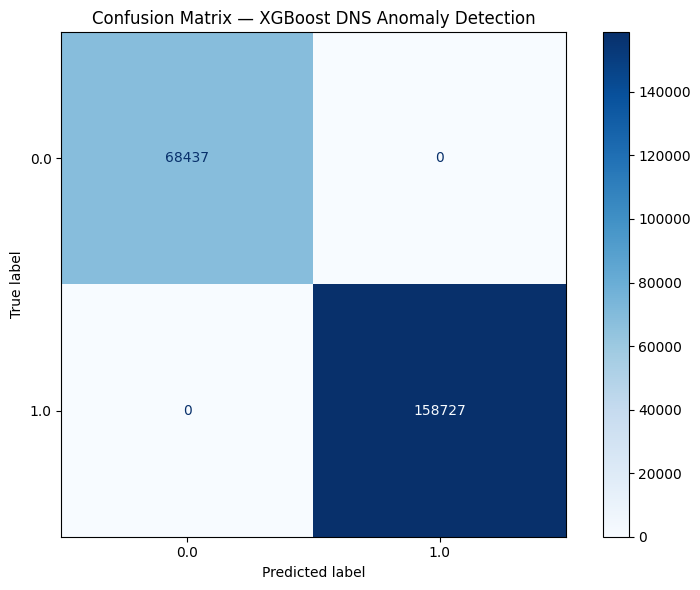


=== False Positive & False Negative Analysis ===
  0.0          | TP=68,437 | FP=     0 | FN=     0 | TN=158,727
  1.0          | TP=158,727 | FP=     0 | FN=     0 | TN=68,437


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le_label.classes_)
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title("Confusion Matrix — XGBoost DNS Anomaly Detection")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("\n=== False Positive & False Negative Analysis ===")
for i, cls in enumerate(le_label.classes_):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - TP - FP - FN
    print(f"  {cls:12s} | TP={TP:6,} | FP={FP:6,} | FN={FN:6,} | TN={TN:6,}")

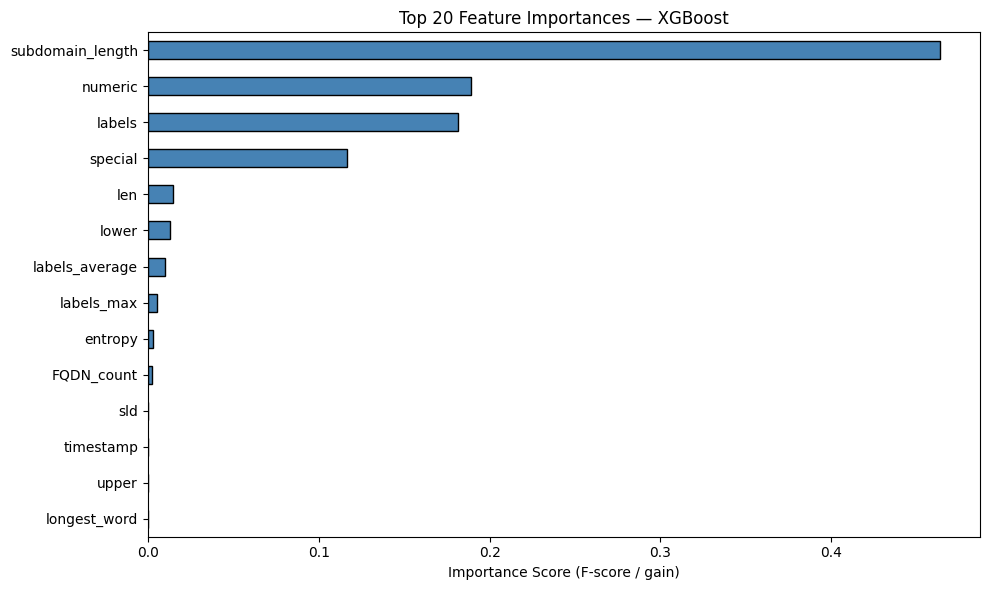


Top 10 most important features:
subdomain_length    0.463842
numeric             0.189413
labels              0.181310
special             0.116740
len                 0.014642
lower               0.013119
labels_average      0.009910
labels_max          0.005572
entropy             0.002855
FQDN_count          0.002487
dtype: float32


In [ ]:
feat_imp = pd.Series(xgb_model.feature_importances_,
                     index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(20).plot(kind='barh', color='steelblue', edgecolor='black')
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances — XGBoost")
plt.xlabel("Importance Score (F-score / gain)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print("\nTop 10 most important features:")
print(feat_imp.head(10))

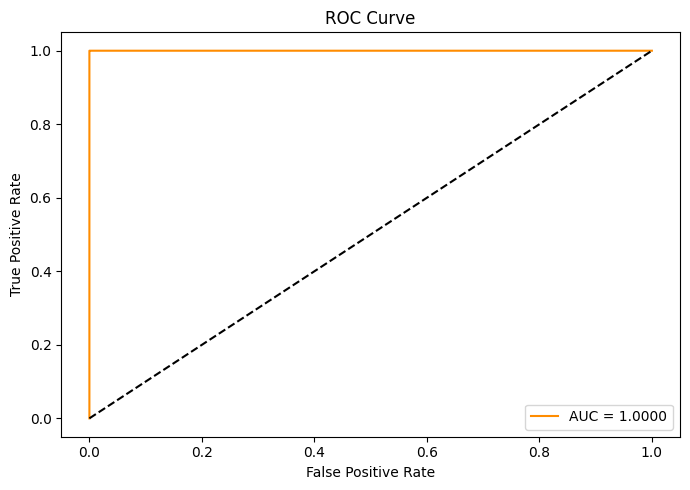

In [ ]:
from sklearn.preprocessing import label_binarize
from itertools import cycle

if num_classes == 2:
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob[:, 1])
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}", color='darkorange')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC Curve"); plt.legend(); plt.tight_layout()
    plt.savefig("roc_curve.png", dpi=150); plt.show()
else:
    y_test_bin = label_binarize(y_test, classes=list(range(num_classes)))
    plt.figure(figsize=(8, 6))
    colors = cycle(['#e74c3c','#2ecc71','#3498db','#9b59b6'])
    for i, (cls, color) in enumerate(zip(le_label.classes_, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
        auc_i = roc_auc_score(y_test_bin[:, i], y_pred_prob[:, i])
        plt.plot(fpr, tpr, color=color, label=f"{cls} (AUC={auc_i:.3f})")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title("ROC Curves (One-vs-Rest)")
    plt.legend(); plt.tight_layout()
    plt.savefig("roc_curve.png", dpi=150); plt.show()